In [1]:
%%javascript
IPython.OutputArea.prototype._should_scroll = function(lines) return false;

<IPython.core.display.Javascript object>

In [2]:
import dataset, plots
import pandas as pd

sp500_components = dataset.SP500.load_historical()

### Dane cenowe z EODHD

Na EODHD dostępnych jest kilka tickerów, dla których można korzystać z danych bezpłatnie. W przypadku akcji amerykańskich są to:
- AAPL.US
- TSLA.US
- VTI.US
- AMZN.US

In [ ]:
demo_key = "demo"
free_tickers = ["AAPL", "TSLA", "VTI", "AMZN"]

dataset.EODHD.download(
    tickers=free_tickers,
    api_key=demo_key,
)

In [ ]:
eodhd_loaded = dataset.EODHD.load()

Number of unique tickers extracted: 4
Saved Close.csv (16209 rows x 1152 columns)
Saved Open.csv (16209 rows x 1152 columns)
Saved High.csv (16209 rows x 1152 columns)
Saved Low.csv (16209 rows x 1152 columns)
Saved Volume.csv (16209 rows x 1152 columns)
Saved Adj_Close.csv (16209 rows x 1152 columns)


Aby pobrać dane o spółkach wycofanych z giełdy trzeba zmapować tickery z submodułu sp500, na te, które istnieją na liście wycofanych tickerów w EODHD.

In [ ]:
delisted_tickers: pd.DataFrame = dataset.EODHD.get_delisted_tickers()

plots.summarize_df(delisted_tickers)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 53832 entries, 0 to 53831
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Code      53832 non-null  str  
 1   Name      53831 non-null  str  
 2   Country   53831 non-null  str  
 3   Exchange  53832 non-null  str  
 4   Currency  53832 non-null  str  
 5   Type      53831 non-null  str  
 6   Isin      16350 non-null  str  
dtypes: str(7)
memory usage: 2.9 MB
None


,Code,Name,Country,Exchange,Currency,Type,Isin
count,53832,53831,53831,53832,53832,53831,16350
unique,53832,49831,2,15,4,10,15954
top,0P0001UM32,Public Storage,USA,NMFQS,USD,Common Stock,US1651677353
freq,1,23,53830,20890,53828,28865,4


,Code,Name,Country,Exchange,Currency,Type,Isin
0,0P0001UM32,Life Cycle Global Select UCITS X USD Acc,USA,PINK,USD,FUND,NaN
1,AAAB,Admiralty Bancorp Inc,USA,NASDAQ,USD,Common Stock,NaN
53830,ZZZ,Cyber Hornet S&P 500 and Bitcoin 75/25 Strateg...,USA,NYSE ARCA,USD,ETF,US45407J4094
53831,ZZZOD,Zinc One Resources Inc,USA,PINK,USD,Common Stock,NaN


In [ ]:
tickers = dataset.SP500.extract_tickers(sp500_components)

dataset.EODHD.download(tickers)

In [4]:
eodhd_data: dict[str, pd.DataFrame] = dataset.EODHD.load()

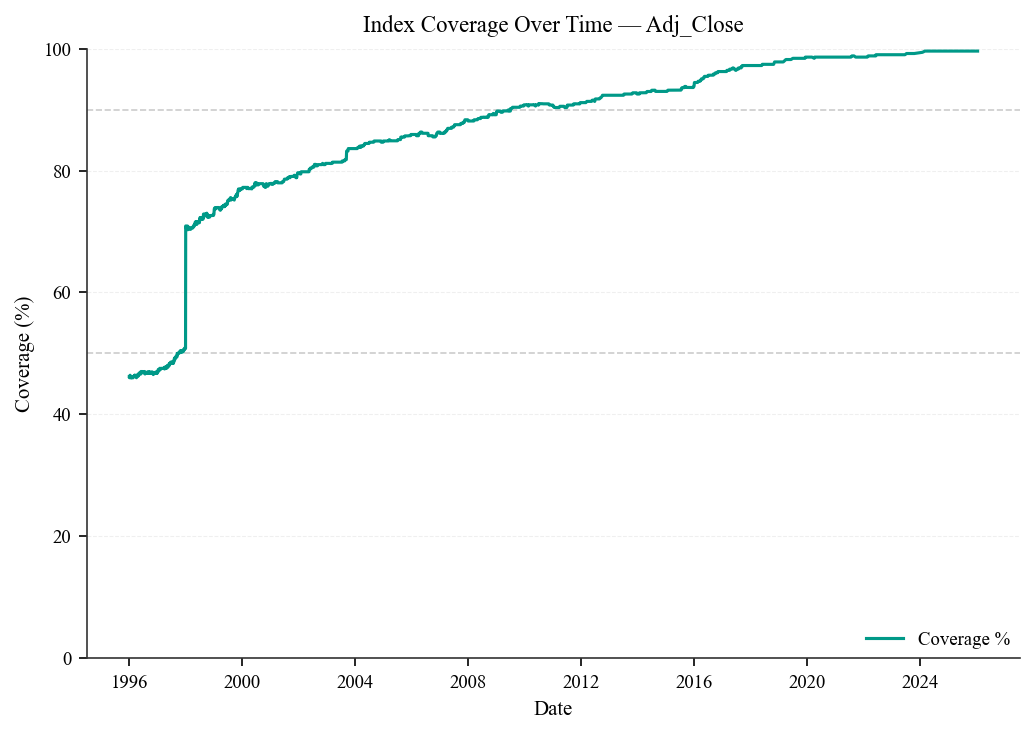

Missing ticker coverage periods:
- AAL:
  missing from 1996-01-02 to 1997-01-13
- AAMRQ:
  not downloaded from 1996-01-02 to 2003-03-10
- ABI:
  missing from 1996-01-02 to 2008-11-20
- ABKFQ:
  not downloaded from 2000-12-11 to 2008-06-10
- ABS:
  missing from 1996-01-02 to 1997-12-29
- ABX:
  missing from 1996-01-02 to 2002-07-18
- ACKH:
  missing from 1996-01-02 to 1997-12-29
- ACV:
  missing from 1996-01-02 to 2006-11-16
- ADCT:
  missing from 1999-08-02 to 2007-06-26
- ADT:
  missing from 2012-10-02 to 2016-04-28
- AET:
  missing from 1996-01-02 to 1997-12-29
- AFS.A:
  not downloaded from 1998-04-08 to 2000-11-29
- AGC:
  missing from 1996-01-02 to 2001-08-20
- AHM:
  missing from 1996-01-02 to 1997-12-29
- AL:
  missing from 1996-01-02 to 2002-07-18
- ALTR:
  missing from 2000-04-18 to 2015-12-21
- AM:
  missing from 1996-01-02 to 2004-04-30
- AMH:
  missing from 1996-01-02 to 1997-09-08
- AMP:
  missing from 1996-01-02 to 1999-03-30
- ANDW:
  missing from 1996-01-02 to 1997-12-2

,available,missing,not_downloaded,total,coverage_pct
count,2705.00000000,2705.00000000,2705.00000000,2705.00000000,2705.00000000
mean,418.65175601,70.59408503,7.50351201,496.74935305,84.15958467
std,68.74797994,57.50922329,7.14298743,5.16624733,13.19684501
min,224.00000000,0.00000000,2.00000000,487.00000000,45.99589322
25%,390.00000000,34.00000000,3.00000000,494.00000000,78.78787879
50%,438.00000000,54.00000000,5.00000000,497.00000000,88.12877264
75%,461.00000000,94.00000000,11.00000000,499.00000000,92.75653924
max,502.00000000,233.00000000,31.00000000,507.00000000,99.60317460


,available,missing,not_downloaded,total,coverage_pct
1996-01-02,225,232,30,487,46.20123203
1996-01-03,225,232,30,487,46.20123203
2025-12-22,501,0,2,503,99.60238569
2026-01-14,501,0,2,503,99.60238569


In [5]:
coverage_df = plots.coverage_over_time(
    stocks_data=eodhd_data,
    components=sp500_components,
    filename="19-eodhd-coverage-over-time.png"
)

plots.summarize_df(coverage_df)

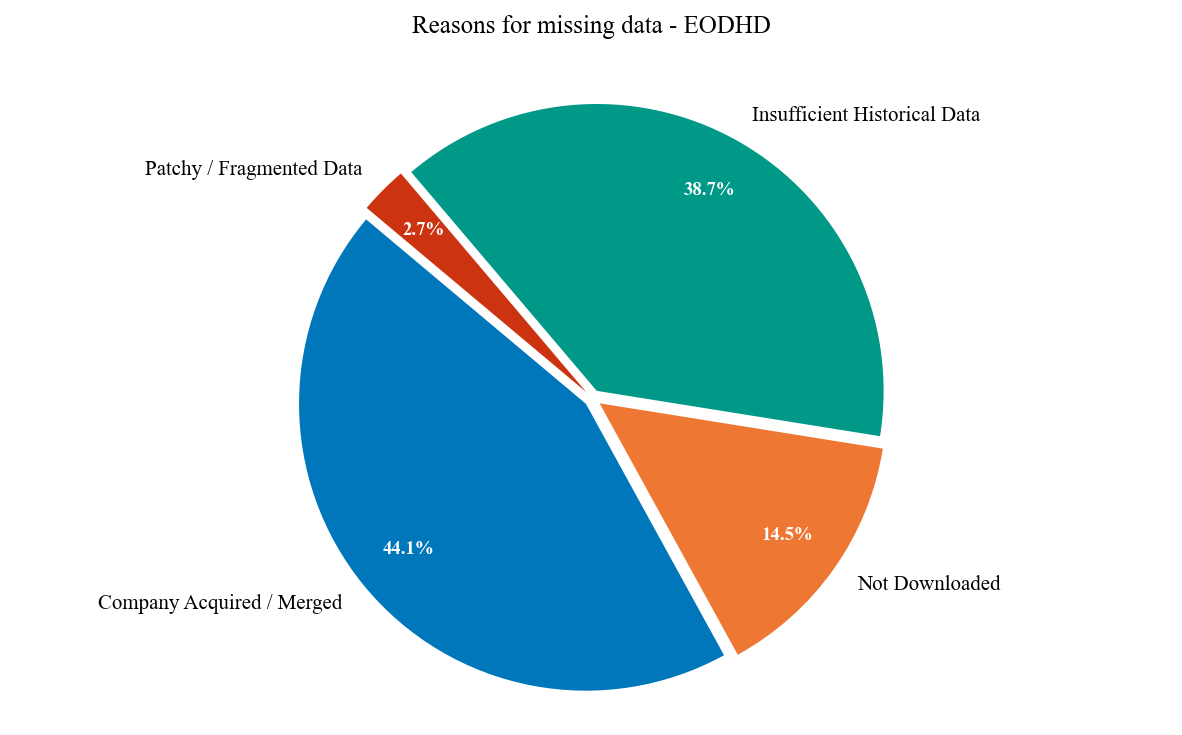

In [6]:
plots.plot_missing_data_reasons("EODHD", filename="20-eodhd-missing-data-reasons.png")

In [14]:
import os, eodhd, pandas as pd, plots

api_key: str = os.getenv("EODHD_API_KEY")
client: eodhd.APIClient = eodhd.APIClient(api_key)
ticker: str = "BUD_old"
api_symbol: str = f"{ticker}.US"
kwargs: dict = {
    "symbol": api_symbol,
    "period": "d",
    "order": "a",
}
raw_data: list = client.get_eod_historical_stock_market_data(**kwargs)
frame: pd.DataFrame = pd.DataFrame(raw_data)
plots.summarize_df(frame)

DataFrame summary:
<class 'pandas.DataFrame'>
RangeIndex: 2738 entries, 0 to 2737
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            2738 non-null   str    
 1   open            2738 non-null   float64
 2   high            2738 non-null   float64
 3   low             2738 non-null   float64
 4   close           2738 non-null   float64
 5   adjusted_close  2738 non-null   float64
 6   volume          2738 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 149.9 KB
None


,open,high,low,close,adjusted_close,volume
count,2738.00000000,2738.00000000,2738.00000000,2738.00000000,2738.00000000,2738.00000000
mean,44.90321512,45.33625676,44.49535829,44.90413879,44.90413879,3162178.46712929
std,9.06532739,9.08338739,9.04698015,9.06036439,9.06036439,3488193.52612240
min,21.56300000,21.71900000,21.46900000,21.71900000,21.71900000,418600.00000000
25%,40.50000000,41.00000000,40.00000000,40.50500000,40.50500000,1838075.00000000
50%,47.03000000,47.48000000,46.70500000,47.08500000,47.08500000,2440650.00000000
75%,50.81750000,51.19000000,50.50000000,50.81000000,50.81000000,3334275.00000000
max,68.90000000,69.26000000,68.54000000,68.58000000,68.58000000,85285104.00000000


,date,open,high,low,close,adjusted_close,volume
0,1997-12-31,22.09400000,22.12500000,21.87500000,22.00000000,22.00000000,916200
1,1998-01-02,21.68800000,22.18800000,21.50000000,22.18800000,22.18800000,940600
2736,2008-11-14,68.00000000,69.26000000,67.60000000,68.50000000,68.50000000,22554000
2737,2008-11-17,68.90000000,68.90000000,68.54000000,68.58000000,68.58000000,8090400
